# 01 - Data Preprocessing & Exploratory Data Analysis

**Dataset:** Student Performance (Portuguese secondary schools, Mathematics course) - `student-mat.csv`

**Goal of this notebook**
1. Load and inspect the raw data.
2. Check data quality (missing values, duplicates, invalid values) and handle outliers.
3. Engineer features and encode categorical variables.
4. Explore the data visually (EDA).
5. Save the processed dataset to `student_processed.csv` for notebooks 02-05.

**Design decisions**
- The saved file is **encoded but not scaled**. Scaling is done in each downstream notebook and fitted on the training split only, which prevents data leakage. Hypothesis tests and decision trees also work better on unscaled, interpretable values.
- **No fitted transformation is applied here.** Anything learned from the data (scaling, quantile-based outlier capping) is deferred to the modelling notebooks, where it is fitted on the training split only. This notebook only applies deterministic, row-wise operations (type fixes, encoding, ratios and sums), which cannot leak information between rows.
- The target `G3` and the interim grades `G1`, `G2` are stored on their **original 0-20 scale**.
- `total_grades` (G1 + G2 + G3) is deliberately **not** created, because it contains the target.

## 1. Setup

In [26]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42

RAW_PATH = Path("../data/student-mat.csv")

OUTPUT_PATH = Path("../data/student_processed.csv")
print(f"Raw data:    {RAW_PATH.resolve()}")
print(f"Output file: {OUTPUT_PATH.resolve()}")

Raw data:    A:\US\Semestr5\Szkoła Zimowa\Projekt\Repo\Data-science\data\student-mat.csv
Output file: A:\US\Semestr5\Szkoła Zimowa\Projekt\Repo\Data-science\data\student_processed.csv


## 2. Data Ingestion

The file uses a semicolon (`;`) as the delimiter.

In [27]:
df_raw = pd.read_csv(RAW_PATH, sep=";")
df_raw.columns = df_raw.columns.str.strip()

print(f"Dataset shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
df_raw.head()

Dataset shape: 395 rows x 33 columns


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


## 3. Data Quality Assessment

We check column types, missing values, duplicates, and whether all values fall within the ranges described in the dataset documentation.

In [28]:
print("=== Column types ===")
print(df_raw.dtypes.value_counts().to_string())

print("\n=== Missing values ===")
n_missing = int(df_raw.isnull().sum().sum())
print(f"Total missing values: {n_missing}")

print(f"\n=== Duplicate rows: {df_raw.duplicated().sum()} ===")

print("\n=== Numerical summary ===")
df_raw.describe().T

=== Column types ===
str      17
int64    16

=== Missing values ===
Total missing values: 0

=== Duplicate rows: 0 ===

=== Numerical summary ===


,count,mean,std,min,25%,50%,75%,max
age,395.0,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
Medu,395.0,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.448101,0.697505,1.0,1.0,1.0,2.0,4.0
studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0
famrel,395.0,3.944304,0.896659,1.0,4.0,4.0,5.0,5.0
freetime,395.0,3.235443,0.998862,1.0,3.0,3.0,4.0,5.0
goout,395.0,3.108861,1.113278,1.0,2.0,3.0,4.0,5.0
Dalc,395.0,1.481013,0.890741,1.0,1.0,1.0,2.0,5.0


In [29]:
# Make sure grade columns are numeric (they are stored as quoted strings in the raw file)
GRADE_COLS = ["G1", "G2", "G3"]
for col in GRADE_COLS:
    df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")
assert df_raw[GRADE_COLS].notna().all().all(), "Non-numeric grade values found"

# Categorical columns: strip whitespace and list the unique values
CATEGORICAL_COLS = df_raw.select_dtypes(exclude="number").columns.tolist()
for col in CATEGORICAL_COLS:
    df_raw[col] = df_raw[col].astype(str).str.strip()

print("=== Unique values of categorical columns ===")
for col in CATEGORICAL_COLS:
    print(f"{col:11s}: {sorted(df_raw[col].unique())}")

=== Unique values of categorical columns ===
school     : ['GP', 'MS']
sex        : ['F', 'M']
address    : ['R', 'U']
famsize    : ['GT3', 'LE3']
Pstatus    : ['A', 'T']
Mjob       : ['at_home', 'health', 'other', 'services', 'teacher']
Fjob       : ['at_home', 'health', 'other', 'services', 'teacher']
reason     : ['course', 'home', 'other', 'reputation']
guardian   : ['father', 'mother', 'other']
schoolsup  : ['no', 'yes']
famsup     : ['no', 'yes']
paid       : ['no', 'yes']
activities : ['no', 'yes']
nursery    : ['no', 'yes']
higher     : ['no', 'yes']
internet   : ['no', 'yes']
romantic   : ['no', 'yes']


In [30]:
# Range validation based on the dataset documentation
range_rules = {
    "age": (15, 22),
    "Medu": (0, 4), "Fedu": (0, 4),
    "traveltime": (1, 4), "studytime": (1, 4), "failures": (0, 4),
    "famrel": (1, 5), "freetime": (1, 5), "goout": (1, 5),
    "Dalc": (1, 5), "Walc": (1, 5), "health": (1, 5),
    "absences": (0, 93),
    "G1": (0, 20), "G2": (0, 20), "G3": (0, 20),
}

violations = {
    col: int(((df_raw[col] < lo) | (df_raw[col] > hi)).sum())
    for col, (lo, hi) in range_rules.items()
}
violations = {k: v for k, v in violations.items() if v > 0}
print("Range violations:", violations if violations else "none")

Range violations: none


## 4. Outlier Analysis

Boxplots and the IQR rule (values beyond 1.5 x IQR from the quartiles) highlight extreme values. `absences` is the only strongly skewed variable. It is **not** modified here: capping at a percentile is a fitted transformation, so the modelling notebooks apply it inside a pipeline using the training split only.

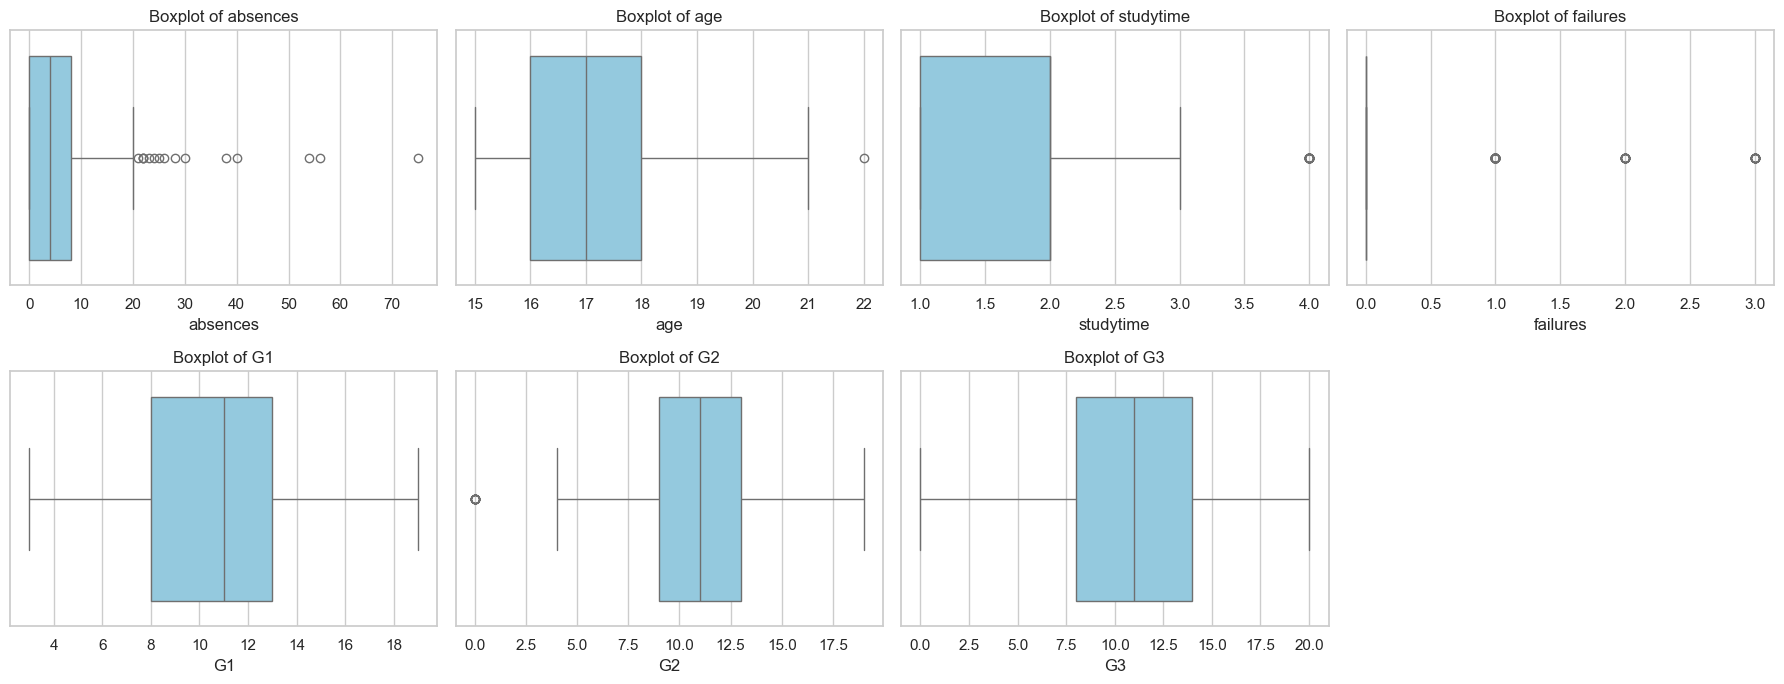

In [31]:
outlier_cols = ["absences", "age", "studytime", "failures", "G1", "G2", "G3"]

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.ravel(), outlier_cols):
    sns.boxplot(x=df_raw[col], ax=ax, color="skyblue")
    ax.set_title(f"Boxplot of {col}")
    ax.set_xlabel(col)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

In [32]:
rows = []
for col in outlier_cols:
    q1, q3 = df_raw[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((df_raw[col] < lo) | (df_raw[col] > hi)).sum())
    rows.append({"feature": col, "lower_bound": lo, "upper_bound": hi,
                 "n_outliers": n_out, "pct_outliers": round(100 * n_out / len(df_raw), 1)})

pd.DataFrame(rows).set_index("feature")

,lower_bound,upper_bound,n_outliers,pct_outliers
feature,,,,
absences,-12.0,20.0,15,3.8
age,13.0,21.0,1,0.3
studytime,-0.5,3.5,27,6.8
failures,0.0,0.0,83,21.0
G1,0.5,20.5,0,0.0
G2,3.0,19.0,13,3.3
G3,-1.0,23.0,0,0.0


## 5. Feature Engineering

Only deterministic, row-wise features are created (each row depends only on its own values):
   - `past_grades = G1 + G2` - aggregate of earlier grades only (no use of `G3`, so no target leakage).
   - `study_to_free_ratio = studytime / freetime` - relative weight of studying versus leisure (`freetime` is always >= 1, so there is no division by zero).

The result, `df_clean`, still has human-readable categories and is used for EDA.

In [33]:
df_clean = df_raw.copy()

# Row-wise feature engineering (no statistics are learned from the data)
assert (df_clean["freetime"] > 0).all()
df_clean["past_grades"] = df_clean["G1"] + df_clean["G2"]
df_clean["study_to_free_ratio"] = df_clean["studytime"] / df_clean["freetime"]

print(f"Shape after feature engineering: {df_clean.shape}")
df_clean[["absences", "G1", "G2", "past_grades", "studytime", "freetime", "study_to_free_ratio"]].describe().T

Shape after feature engineering: (395, 35)


,count,mean,std,min,25%,50%,75%,max
absences,395.0,5.708861,8.003096,0.0,0.0,4.000000,8.0,75.0
G1,395.0,10.908861,3.319195,3.0,8.0,11.000000,13.0,19.0
G2,395.0,10.713924,3.761505,0.0,9.0,11.000000,13.0,19.0
past_grades,395.0,21.622785,6.814957,4.0,17.0,22.000000,26.0,38.0
studytime,395.0,2.035443,0.839240,1.0,1.0,2.000000,2.0,4.0
freetime,395.0,3.235443,0.998862,1.0,3.0,3.000000,4.0,5.0
study_to_free_ratio,395.0,0.738987,0.538360,0.2,0.4,0.666667,1.0,4.0


## 6. Exploratory Data Analysis

### 6.1 Target variable: final grade (G3)

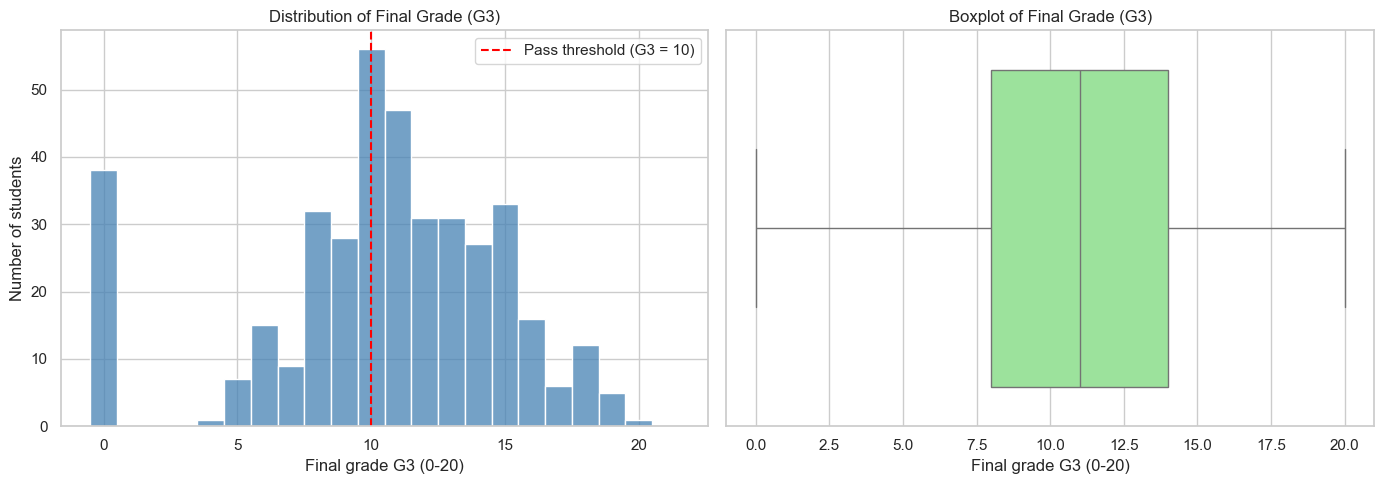

Mean G3: 10.42 | Median G3: 11.0 | Std: 4.58
Students with G3 = 0: 38 (9.6%)
Pass rate (G3 >= 10): 67.1%


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean["G3"], bins=21, binrange=(0, 21), discrete=True, kde=False,
             color="steelblue", ax=axes[0])
axes[0].axvline(10, color="red", linestyle="--", label="Pass threshold (G3 = 10)")
axes[0].set_title("Distribution of Final Grade (G3)")
axes[0].set_xlabel("Final grade G3 (0-20)")
axes[0].set_ylabel("Number of students")
axes[0].legend()

sns.boxplot(x=df_clean["G3"], color="lightgreen", ax=axes[1])
axes[1].set_title("Boxplot of Final Grade (G3)")
axes[1].set_xlabel("Final grade G3 (0-20)")

plt.tight_layout()
plt.show()

n_zero = int((df_clean["G3"] == 0).sum())
pass_rate = (df_clean["G3"] >= 10).mean()
print(f"Mean G3: {df_clean['G3'].mean():.2f} | Median G3: {df_clean['G3'].median():.1f} | Std: {df_clean['G3'].std():.2f}")
print(f"Students with G3 = 0: {n_zero} ({100 * n_zero / len(df_clean):.1f}%)")
print(f"Pass rate (G3 >= 10): {100 * pass_rate:.1f}%")

The distribution is roughly bell-shaped around 10-11, with a distinct spike at `G3 = 0`. These zeros most likely represent students who did not take the final evaluation (dropouts), not genuinely very low performance - an important caveat for the regression models in notebook 03.

### 6.2 Grade progression: G1 -> G2 -> G3

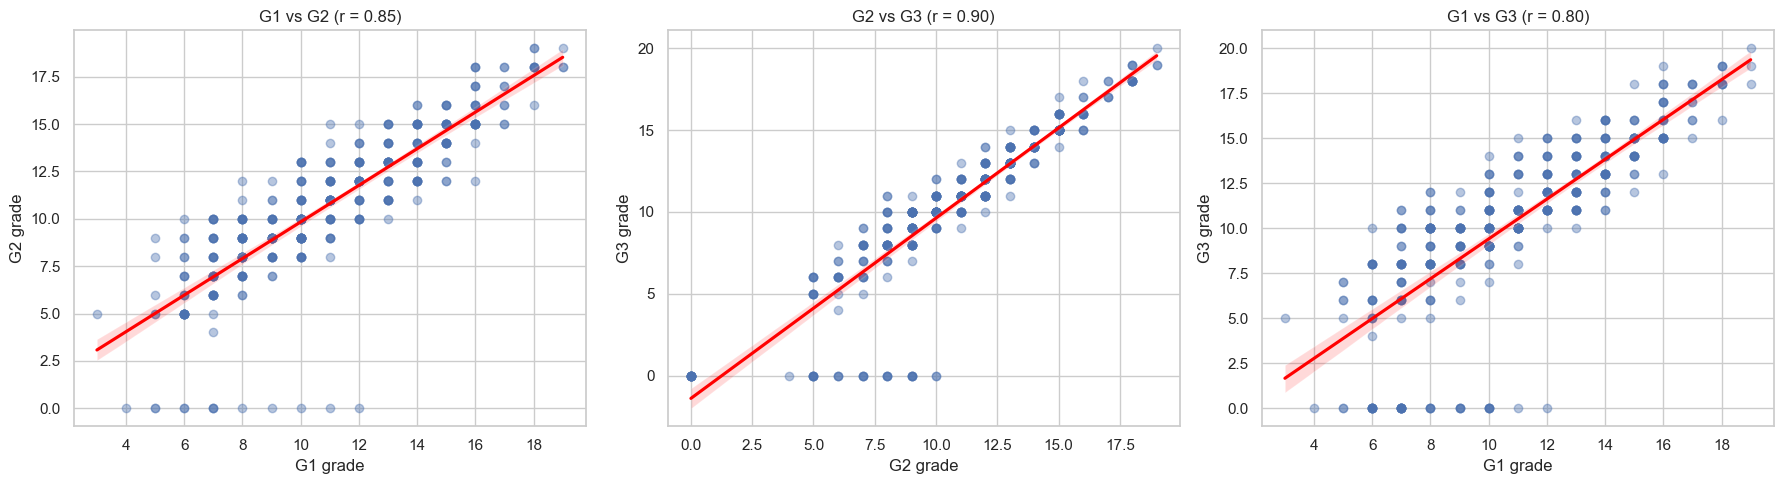

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pairs = [("G1", "G2"), ("G2", "G3"), ("G1", "G3")]
for ax, (x_col, y_col) in zip(axes, pairs):
    sns.regplot(data=df_clean, x=x_col, y=y_col, scatter_kws={"alpha": 0.4}, line_kws={"color": "red"}, ax=ax)
    corr = df_clean[x_col].corr(df_clean[y_col])
    ax.set_title(f"{x_col} vs {y_col} (r = {corr:.2f})")
    ax.set_xlabel(f"{x_col} grade")
    ax.set_ylabel(f"{y_col} grade")

plt.tight_layout()
plt.show()

Earlier grades are extremely strong predictors of the final grade (G2 vs G3 in particular). The points with `G3 = 0` and non-zero `G2` are the dropout cases noted above.

### 6.3 Numerical features

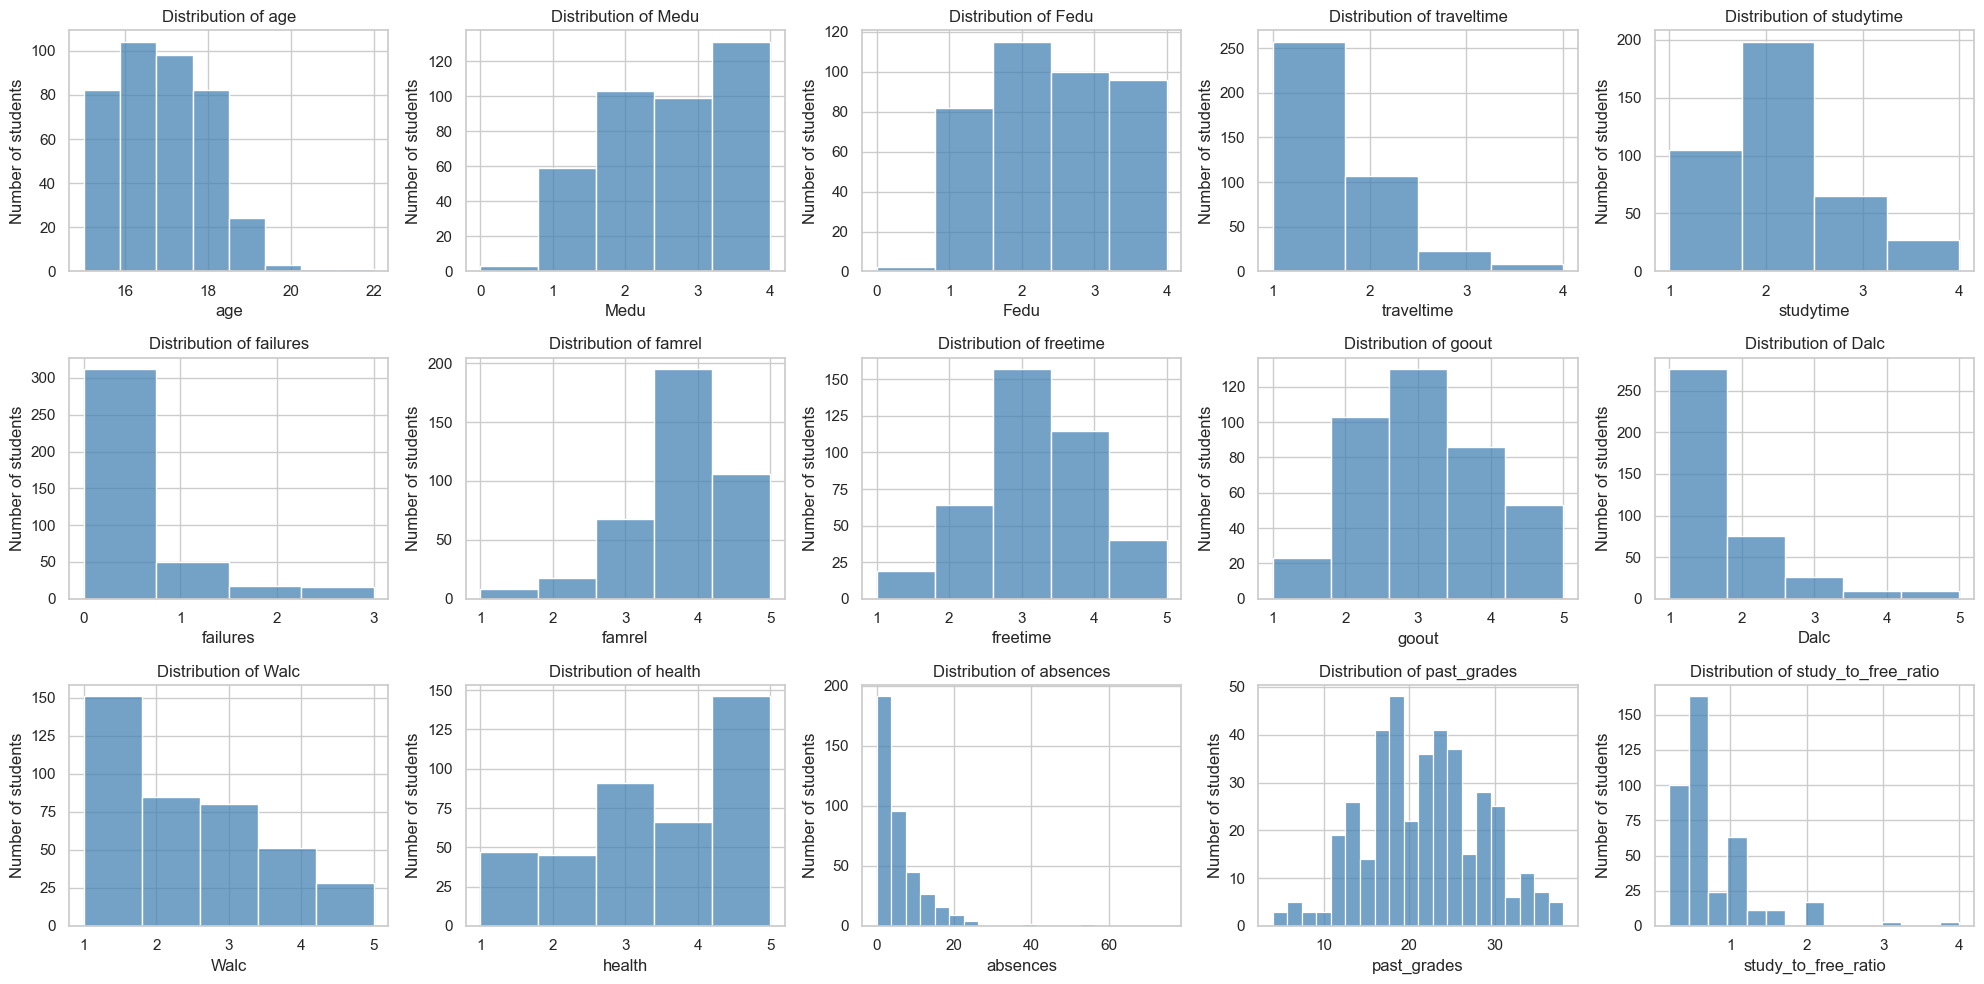

In [36]:
numeric_features = ["age", "Medu", "Fedu", "traveltime", "studytime", "failures", "famrel",
                    "freetime", "goout", "Dalc", "Walc", "health", "absences", "past_grades",
                    "study_to_free_ratio"]

fig, axes = plt.subplots(3, 5, figsize=(20, 10))
for ax, col in zip(axes.ravel(), numeric_features):
    sns.histplot(df_clean[col], bins=min(20, df_clean[col].nunique()), color="steelblue", ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Number of students")
plt.tight_layout()
plt.show()

### 6.4 Categorical features

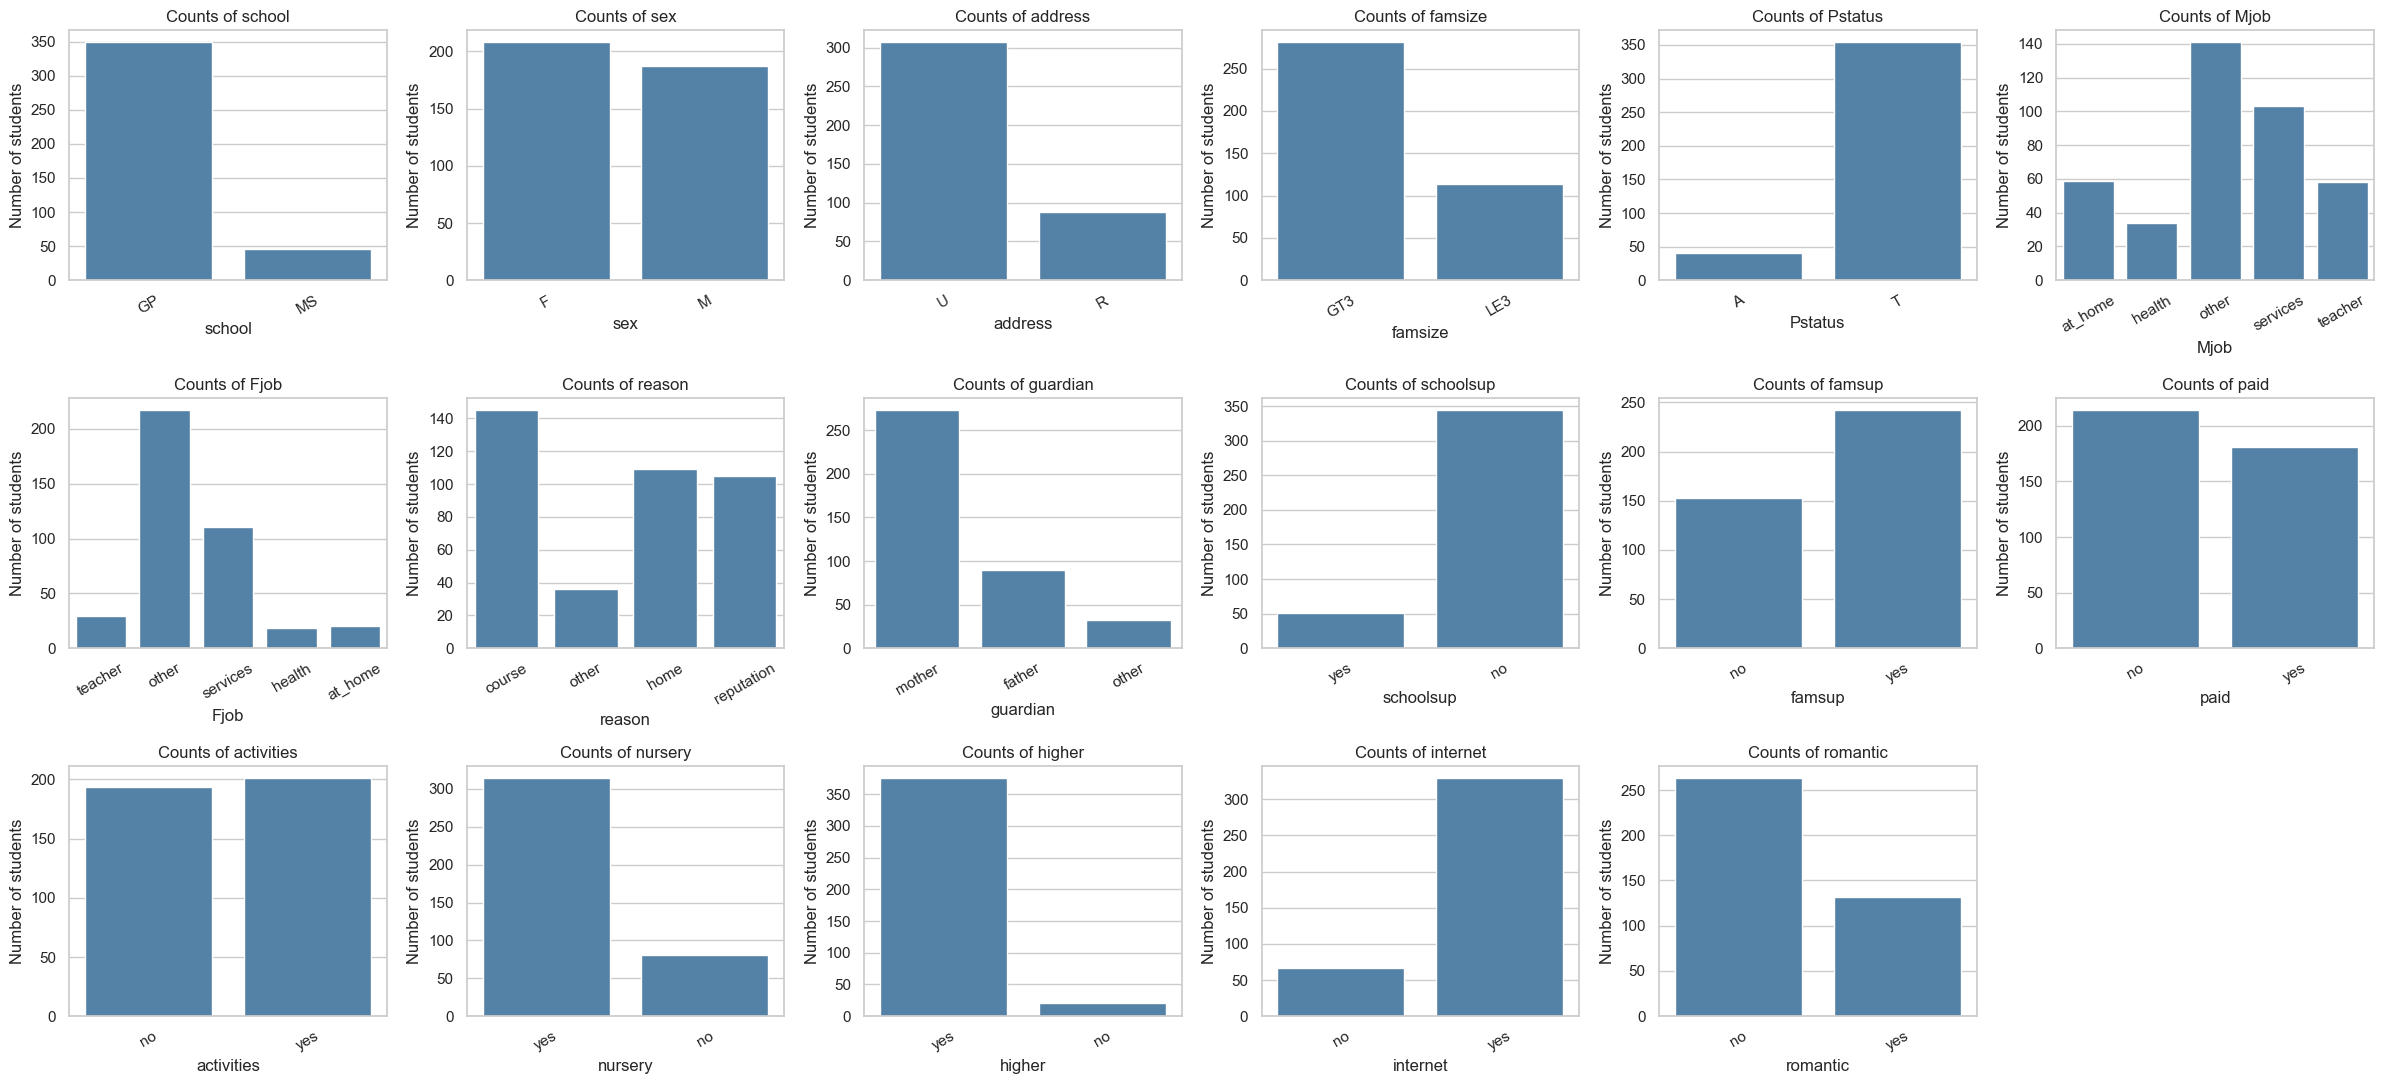

In [37]:
cat_features = CATEGORICAL_COLS  # all non-numeric columns of the raw data

fig, axes = plt.subplots(3, 6, figsize=(24, 11))
for ax, col in zip(axes.ravel(), cat_features):
    sns.countplot(data=df_clean, x=col, color="steelblue", ax=ax)
    ax.set_title(f"Counts of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Number of students")
    ax.tick_params(axis="x", rotation=30)
for ax in axes.ravel()[len(cat_features):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

### 6.5 Relationship between features and the final grade

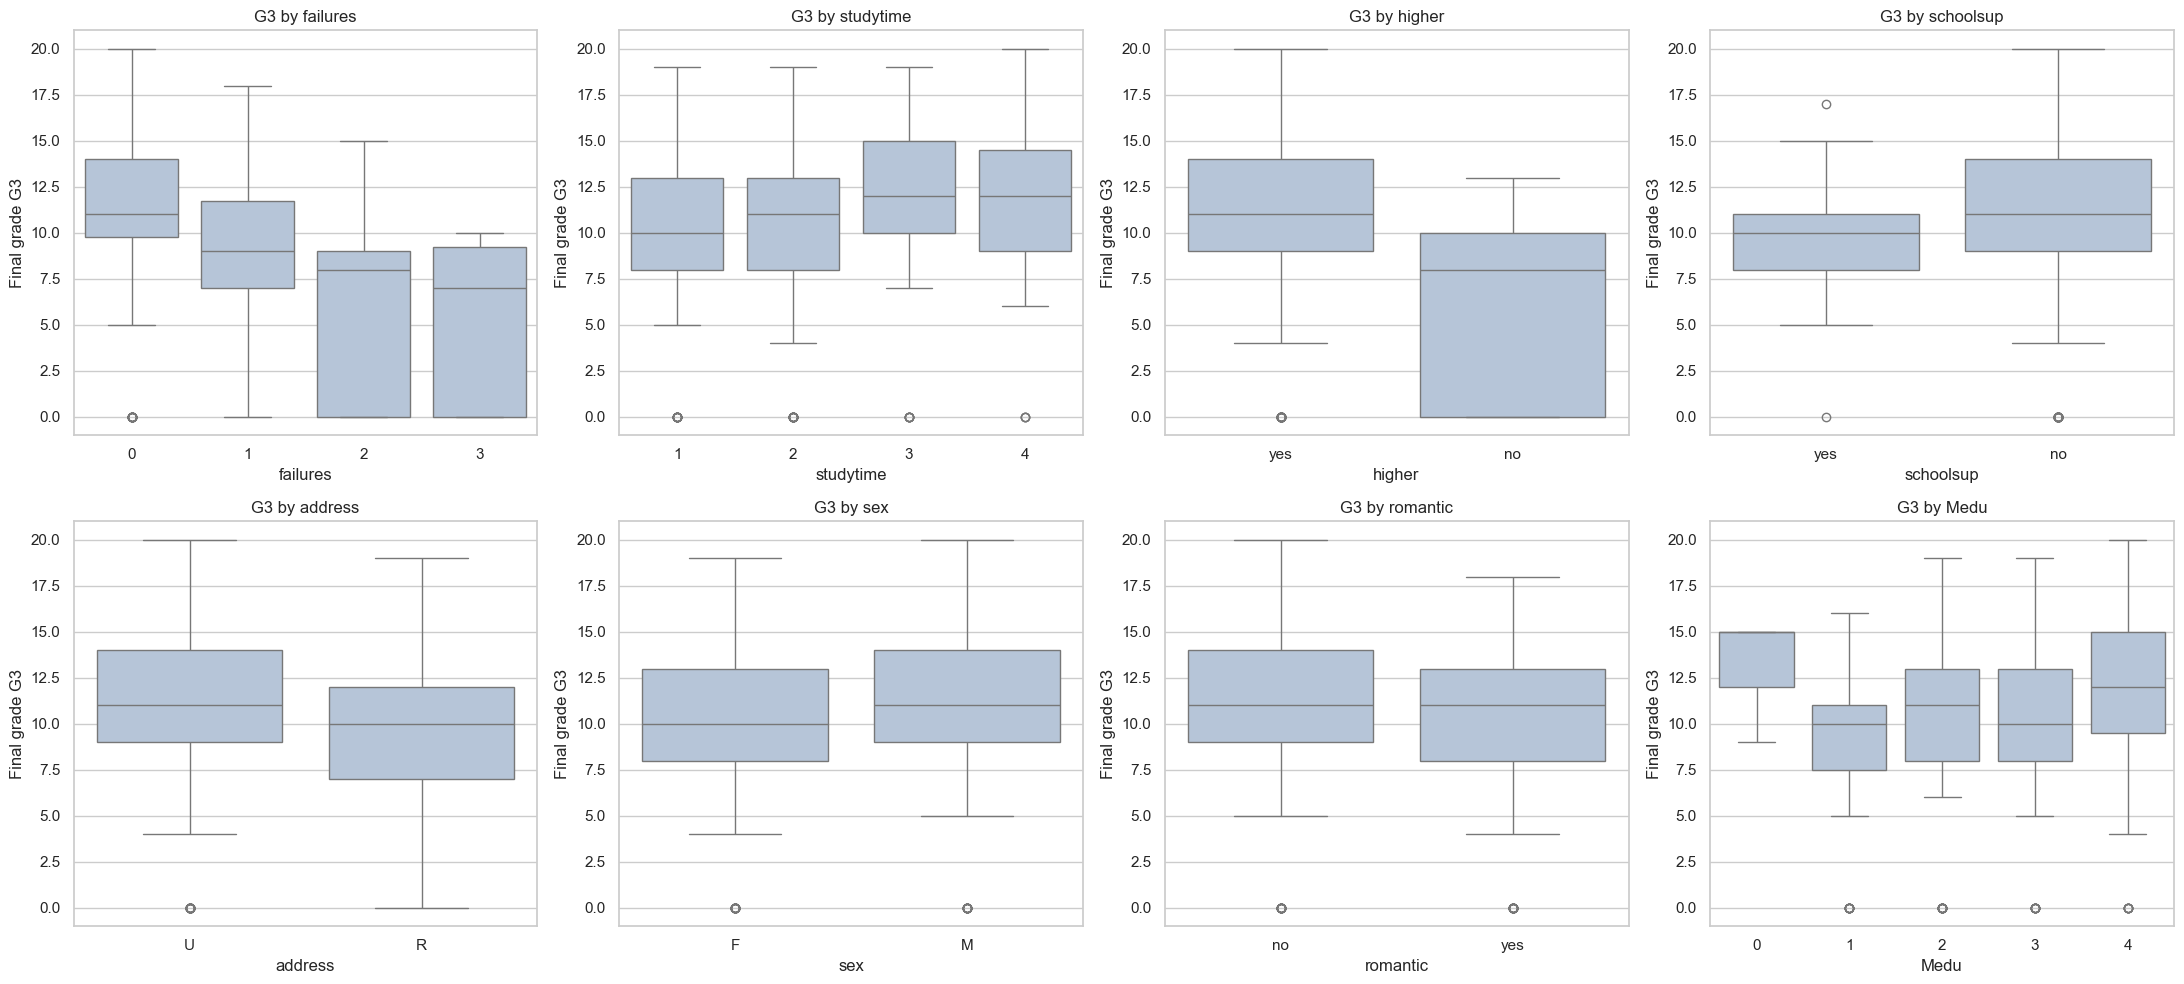

In [38]:
selected = ["failures", "studytime", "higher", "schoolsup", "address", "sex", "romantic", "Medu"]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for ax, col in zip(axes.ravel(), selected):
    sns.boxplot(data=df_clean, x=col, y="G3", color="lightsteelblue", ax=ax)
    ax.set_title(f"G3 by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Final grade G3")
plt.tight_layout()
plt.show()

In [39]:
# Mean G3 and pass rate per group for the binary yes/no style features
summary_rows = []
for col in ["higher", "schoolsup", "famsup", "paid", "internet", "romantic", "address", "sex", "school"]:
    grp = df_clean.groupby(col)["G3"].agg(mean_G3="mean", n="count")
    grp["pass_rate_%"] = df_clean.groupby(col)["G3"].apply(lambda s: 100 * (s >= 10).mean())
    grp.insert(0, "feature", col)
    summary_rows.append(grp.reset_index().rename(columns={col: "group"}))

pd.concat(summary_rows, ignore_index=True).round(2)

,group,feature,mean_G3,n,pass_rate_%
0,no,higher,6.80,20,35.00
1,yes,higher,10.61,375,68.80
2,no,schoolsup,10.56,344,68.90
3,yes,schoolsup,9.43,51,54.90
4,no,famsup,10.64,153,70.59
5,yes,famsup,10.27,242,64.88
6,no,paid,9.99,214,63.08
7,yes,paid,10.92,181,71.82
8,no,internet,9.41,66,60.61
9,yes,internet,10.62,329,68.39


## 7. Categorical Encoding

| Column(s) | Encoding |
|---|---|
| `school` | GP = 1, MS = 0 |
| `sex` | F = 1, M = 0 |
| `address` | U (urban) = 1, R (rural) = 0 |
| `famsize` | GT3 = 1, LE3 = 0 |
| `Pstatus` | T (together) = 1, A (apart) = 0 |
| `schoolsup`, `famsup`, `paid`, `activities`, `nursery`, `higher`, `internet`, `romantic` | yes = 1, no = 0 |
| `Mjob`, `Fjob`, `reason`, `guardian` | one-hot encoding (`drop_first=True`, integer 0/1) |

In [40]:
df_processed = df_clean.copy()

binary_mappings = {
    "school":     {"GP": 1, "MS": 0},
    "sex":        {"F": 1, "M": 0},
    "address":    {"U": 1, "R": 0},
    "famsize":    {"GT3": 1, "LE3": 0},
    "Pstatus":    {"T": 1, "A": 0},
}
yes_no_cols = ["schoolsup", "famsup", "paid", "activities", "nursery", "higher", "internet", "romantic"]
binary_mappings.update({col: {"yes": 1, "no": 0} for col in yes_no_cols})

for col, mapping in binary_mappings.items():
    df_processed[col] = df_processed[col].map(mapping)
    assert df_processed[col].notna().all(), f"Unmapped value in {col}"

multi_class_cols = ["Mjob", "Fjob", "reason", "guardian"]
df_processed = pd.get_dummies(df_processed, columns=multi_class_cols, drop_first=True, dtype=int)

print(f"Shape after encoding: {df_processed.shape}")
df_processed.head()

Shape after encoding: (395, 44)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,past_grades,study_to_free_ratio,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,1,1,18,1,1,0,4,4,2,2,0,1,0,0,0,1,1,0,0,4,3,4,1,1,3,6,5,6,6,11,0.666667,0,0,0,0,0,0,0,1,0,0,0,1,0
1,1,1,17,1,1,1,1,1,1,2,0,0,1,0,0,0,1,1,0,5,3,3,1,1,3,4,5,5,6,10,0.666667,0,0,0,0,0,1,0,0,0,0,0,0,0
2,1,1,15,1,0,1,1,1,1,2,3,1,0,1,0,1,1,1,0,4,3,2,2,3,3,10,7,8,10,15,0.666667,0,0,0,0,0,1,0,0,0,1,0,1,0
3,1,1,15,1,1,1,4,2,1,3,0,0,1,1,1,1,1,1,1,3,2,2,1,1,5,2,15,14,15,29,1.500000,1,0,0,0,0,0,1,0,1,0,0,1,0
4,1,1,16,1,1,1,3,3,1,2,0,0,1,1,0,1,1,0,0,4,3,2,1,2,5,4,6,10,10,16,0.666667,0,1,0,0,0,1,0,0,1,0,0,0,0


### 7.1 Correlation analysis on the processed data

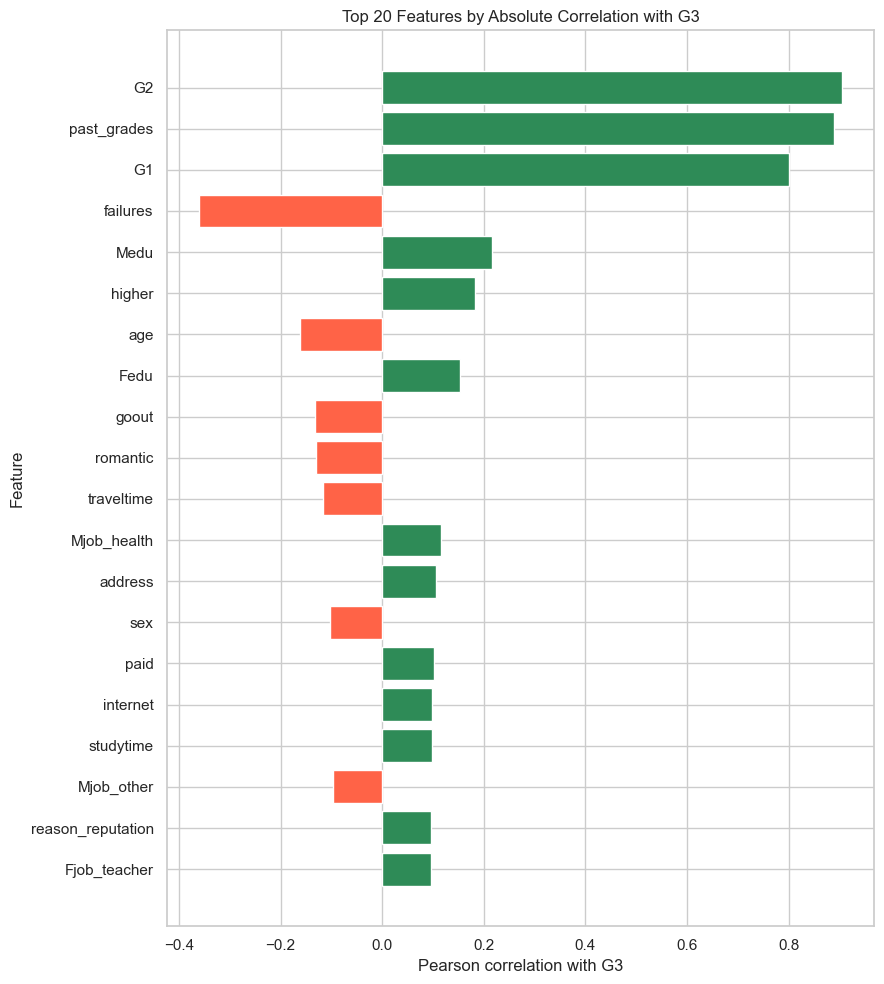

In [41]:
corr_with_target = (
    df_processed.corr(numeric_only=True)["G3"]
    .drop("G3")
    .sort_values(key=np.abs, ascending=False)
)

plt.figure(figsize=(9, 10))
top = corr_with_target.head(20).iloc[::-1]
colors = ["tomato" if v < 0 else "seagreen" for v in top]
plt.barh(top.index, top.values, color=colors)
plt.title("Top 20 Features by Absolute Correlation with G3")
plt.xlabel("Pearson correlation with G3")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

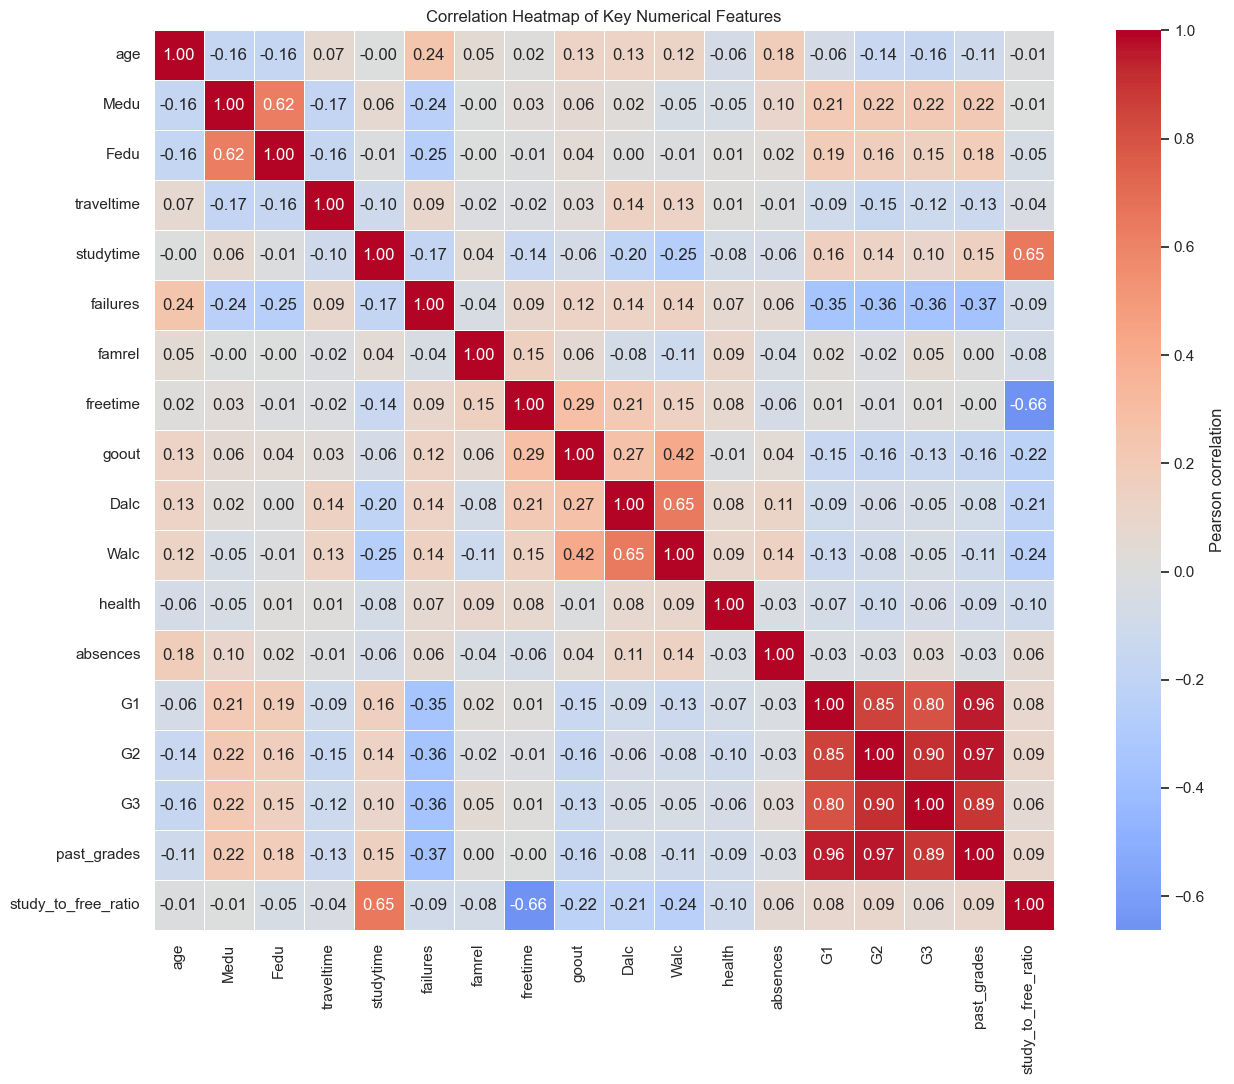

In [42]:
key_features = ["age", "Medu", "Fedu", "traveltime", "studytime", "failures", "famrel",
                "freetime", "goout", "Dalc", "Walc", "health", "absences",
                "G1", "G2", "G3", "past_grades", "study_to_free_ratio"]

plt.figure(figsize=(14, 11))
sns.heatmap(df_processed[key_features].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True, cbar_kws={"label": "Pearson correlation"})
plt.title("Correlation Heatmap of Key Numerical Features")
plt.tight_layout()
plt.show()

**Key observations**
- `G2` and `G1` dominate the correlation with `G3`; `failures` is the strongest negative non-grade predictor.
- `Dalc` and `Walc` (alcohol consumption) and `Medu` / `Fedu` (parents' education) are correlated with each other, which is relevant for regression multicollinearity checks.
- Lifestyle variables (`freetime`, `health`, `famrel`) have weak linear relationships with the final grade.

## 8. Final Validation & Export

Before saving we verify that the processed dataset has no missing values and only numeric columns, and that the row count is unchanged.

In [43]:
assert df_processed.shape[0] == df_raw.shape[0], "Row count changed during preprocessing"
assert df_processed.isnull().sum().sum() == 0, "Missing values in processed data"
assert all(pd.api.types.is_numeric_dtype(t) for t in df_processed.dtypes), "Non-numeric column found"

print(f"Processed dataset: {df_processed.shape[0]} rows x {df_processed.shape[1]} columns")
print("\nColumns:")
print(list(df_processed.columns))

Processed dataset: 395 rows x 44 columns

Columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'past_grades', 'study_to_free_ratio', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother', 'guardian_other']


In [44]:
df_processed.to_csv(OUTPUT_PATH, index=False)
print(f"Saved processed dataset to: {OUTPUT_PATH.resolve()}")

# Round-trip check: reload and compare
df_check = pd.read_csv(OUTPUT_PATH)
assert df_check.shape == df_processed.shape
assert list(df_check.columns) == list(df_processed.columns)
assert np.allclose(df_check.values, df_processed.values)
print("Round-trip check passed.")
df_check.head()

Saved processed dataset to: A:\US\Semestr5\Szkoła Zimowa\Projekt\Repo\Data-science\data\student_processed.csv
Round-trip check passed.


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,past_grades,study_to_free_ratio,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,1,1,18,1,1,0,4,4,2,2,0,1,0,0,0,1,1,0,0,4,3,4,1,1,3,6,5,6,6,11,0.666667,0,0,0,0,0,0,0,1,0,0,0,1,0
1,1,1,17,1,1,1,1,1,1,2,0,0,1,0,0,0,1,1,0,5,3,3,1,1,3,4,5,5,6,10,0.666667,0,0,0,0,0,1,0,0,0,0,0,0,0
2,1,1,15,1,0,1,1,1,1,2,3,1,0,1,0,1,1,1,0,4,3,2,2,3,3,10,7,8,10,15,0.666667,0,0,0,0,0,1,0,0,0,1,0,1,0
3,1,1,15,1,1,1,4,2,1,3,0,0,1,1,1,1,1,1,1,3,2,2,1,1,5,2,15,14,15,29,1.500000,1,0,0,0,0,0,1,0,1,0,0,1,0
4,1,1,16,1,1,1,3,3,1,2,0,0,1,1,0,1,1,0,0,4,3,2,1,2,5,4,6,10,10,16,0.666667,0,1,0,0,0,1,0,0,1,0,0,0,0


## 9. Summary & Hand-off to Next Notebooks

`student_processed.csv` contains:
- **Original numeric columns** (age, parental education, study time, failures, social/health ratings, absences, `G1`, `G2`, `G3`) - unscaled; `absences` is kept in its raw form (outlier capping is done later, inside the modelling pipelines).
- **Engineered features:** `past_grades`, `study_to_free_ratio`.
- **Binary-encoded columns:** `school`, `sex`, `address`, `famsize`, `Pstatus`, `schoolsup`, `famsup`, `paid`, `activities`, `nursery`, `higher`, `internet`, `romantic` (1/0 as in the table above).
- **One-hot columns:** `Mjob_*`, `Fjob_*`, `reason_*`, `guardian_*` (first category dropped).

**Notes for the next notebooks**
- `02_hypothesis_testing`: use `address` (1 = urban), `higher`, `romantic` and `G3` directly.
- `03_predictive_modelling`: split first, then fit the `absences` cap and the `StandardScaler` on the training set only (inside a `Pipeline`); drop `G3` from the features and do not use `past_grades` together with `G1` and `G2` (it is their exact sum).
- `04_classification`: create the target `passed = (G3 >= 10)`; drop `G1`, `G2`, `G3`, `past_grades` from the features to avoid leakage.
- `05_clustering`: exclude `G3`, then cap `absences` and scale the features inside a pipeline before K-Means.